In [74]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/penguins_cleaned.csv"
df = pd.read_csv(url)
df.head(1)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,male


In [75]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')

In [76]:
for c in df.columns:
    print(c)

species
island
bill_length_mm
bill_depth_mm
flipper_length_mm
body_mass_g
sex


In [77]:
df.corr(numeric_only= True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


In [78]:
x_str = "body_mass_g"
y_str = "flipper_length_mm"
x= df[x_str]
y = df[y_str]
type(x)

pandas.Series

<function matplotlib.pyplot.show(close=None, block=None)>

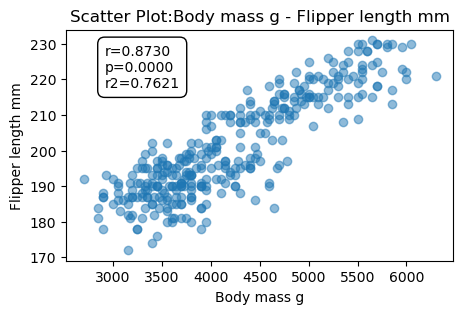

In [79]:
r, p = stats.pearsonr(x, y)
r2 = r**2 

x_name = (x_str.replace("_", " ")).capitalize()
y_name = (y_str.replace("_", " ")).capitalize()
plt.figure(figsize=(5, 3))
plt.scatter(x, y, alpha= 0.5)
plt.title(f"Scatter Plot:{x_name} - {y_name}")
plt.xlabel(x_name)
plt.ylabel(y_name)
text = f"""r={r:.4f}
p={p:.4f}
r2={r2:.4f}"""
plt.text(
    0.1,
    0.75,
    text,
    transform= plt.gca().transAxes,
    bbox= {"boxstyle": "round, pad = 0.5", "fc": "white"}
)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

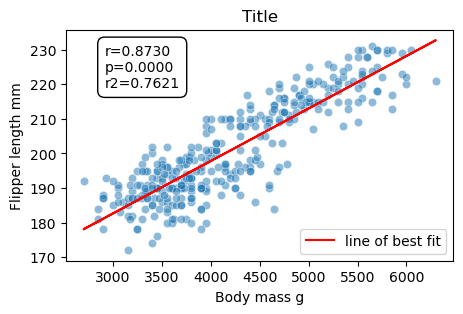

In [80]:
#scatter plot with seaborn
plt.figure(figsize=(5,3))
scat = sns.scatterplot(data=df, x=x_str, y= y_str, alpha = 0.5)
scat.set(xlabel=x_name, ylabel= y_name, title = "Title")
scat.text(
    0.1,
    0.75,
    text,
    transform= scat.transAxes,
    bbox= {"boxstyle": "round, pad = 0.5", "fc": "white"}
)
m, b, r, p, err = stats.linregress(x,y)
line = m * x + b
plt.plot(x, line, color = "r", label ="line of best fit")
plt.legend()
plt.show

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

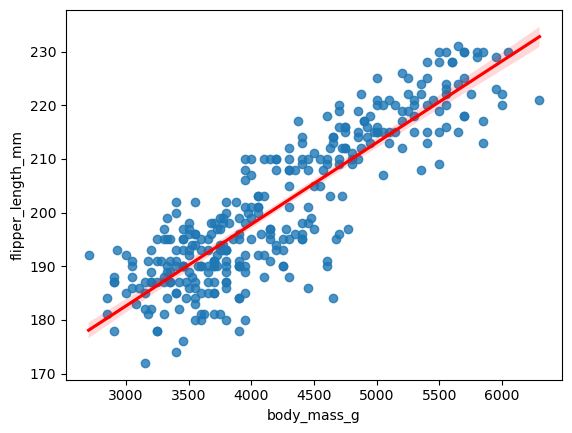

In [81]:
sns.regplot(data=df, x=x_str, y=y_str, line_kws={"color": "red", "label": "Line of Best Fit."})
plt.legend

In [82]:
species = df["species"].unique()
species

<StringArray>
['Adelie', 'Gentoo', 'Chinstrap']
Length: 3, dtype: str

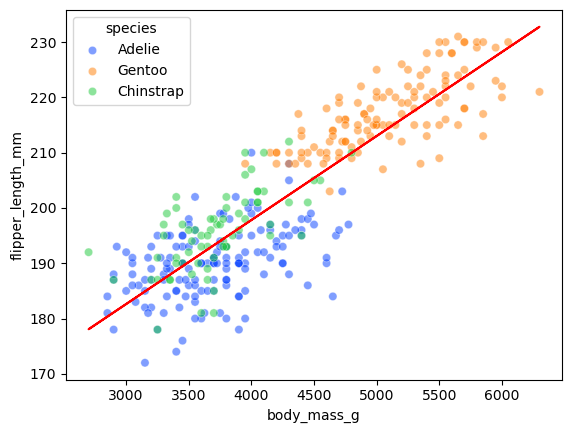

In [86]:
sns.scatterplot(data=df, x= x_str, y = y_str, hue = "species", palette = "bright", alpha = 0.5)
plt.plot(x,line, color = "r")

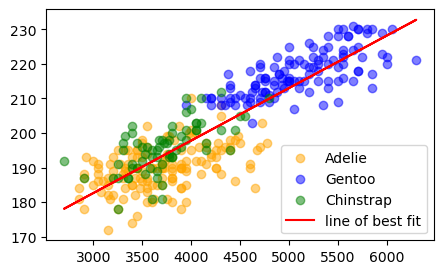

In [92]:
plt.figure(figsize=(5,3))
colors = ["orange", "blue", "green"]
for s in species:
    subset = df.loc[df["species"] == s]
    plt.scatter(subset[x_str], subset[y_str], color = colors.pop(0), alpha=0.5, label = s)
   
plt.plot(x,line, color="r", label = "line of best fit") 
plt.legend()
plt.show()

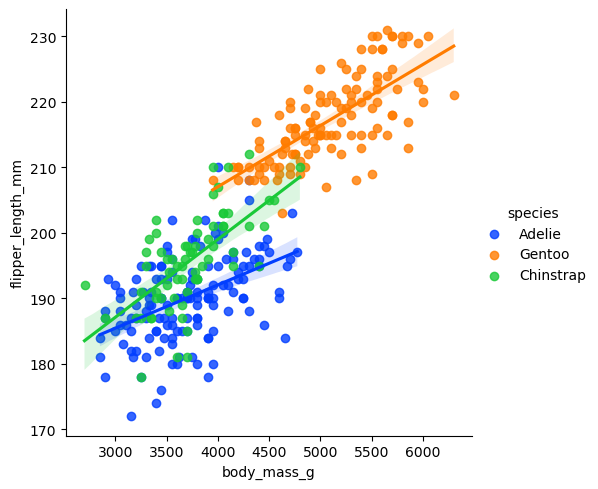

In [94]:
sns.lmplot(
    data=df,
    x=x_str,
    y=y_str,
    hue = "species",
    palette= "bright"
)

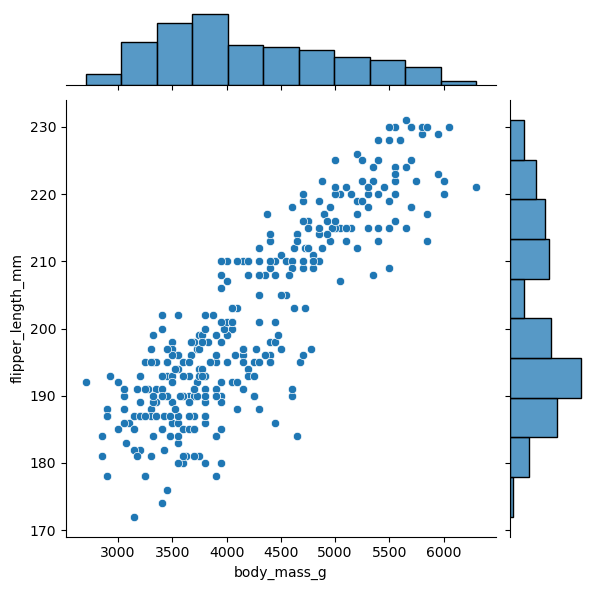

In [96]:
sns.jointplot(data=df, x = x_str, y = y_str)

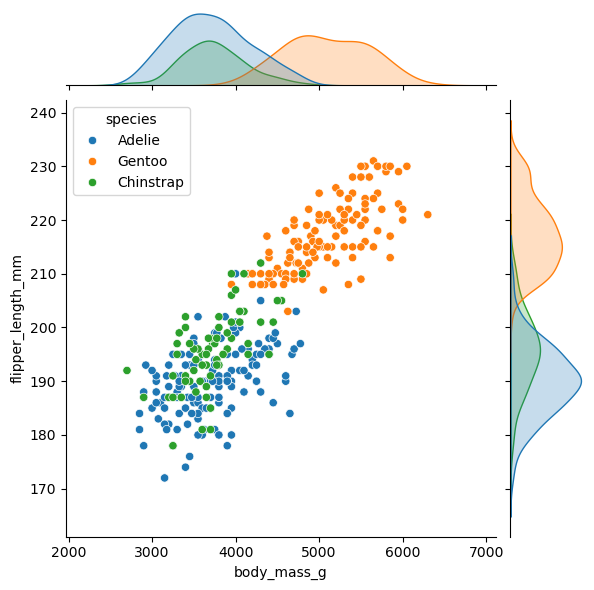

In [95]:
sns.jointplot(data=df, x = x_str, y = y_str, kind = "scatter", hue = "species")